In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix,make_scorer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef, ConfusionMatrixDisplay


## Loading Dataset

In [2]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

## Separating Features and Label

In [4]:
X = df.drop('HeartDisease', axis = 1)
y = df['HeartDisease']
print(X.shape, y.shape)

(918, 11) (918,)


In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Encoding Categorical Features

In [6]:
# ohe = OneHotEncoder(drop='first',sparse=False,handle_unknown='infrequent_if_exist',dtype = np.int64)
ohe = OneHotEncoder(drop='first',sparse=False,handle_unknown='infrequent_if_exist',dtype = np.int64)
# print(X_train.shape,X_test.shape)

X_ohe = ohe.fit_transform(X[['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope']])

# X_test_ohe = ohe.transform(X_test[['gender', 'smoking_history']])

print(X_ohe.shape)


(918, 9)


C:\Users\JAWAD\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [7]:
X_ohe_encoded_df = pd.DataFrame(X_ohe, columns=ohe.get_feature_names_out(), index=X.index)
X_ohe_encoded_df

,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,1,1,0,0,1,0,0,0,1
1,0,0,1,0,1,0,0,1,0
2,1,1,0,0,0,1,0,0,1
3,0,0,0,0,1,0,1,1,0
4,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...
913,1,0,0,1,1,0,0,1,0
914,1,0,0,0,1,0,0,1,0
915,1,0,0,0,1,0,1,1,0
916,0,1,0,0,0,0,0,1,0


In [8]:
X = X.drop(columns=['Sex', 'ChestPainType','RestingECG','ExerciseAngina','ST_Slope']).join(X_ohe_encoded_df)
# X_test = X_test.drop(columns=['gender', 'city']).join(test_nominal_encoded_df)
X

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3.4,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1.2,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0.0,0,1,0,0,0,0,0,1,0


## Applying Feature Scaling

In [9]:
mms = MinMaxScaler()

X = mms.fit_transform(X)
# X_test_transformed = mms.transform(X_test_transformed)

## Define K-Fold Cross-Validation


In [10]:
k = 5  # 5-Fold Cross Validation
kf = KFold(n_splits=k)

## Defining and Traning ML Model

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier,BaggingClassifier,RandomForestClassifier,ExtraTreesClassifier,StackingClassifier
from sklearn.svm import SVC

# clf = DecisionTreeClassifier(max_depth=14,criterion='entropy',min_samples_split=25,min_samples_leaf=9,max_features=8,random_state=42)
# clf = GradientBoostingClassifier(n_estimators=27,max_depth=12,min_samples_split=20,random_state=42)
# clf = BaggingClassifier(estimator=SVC(kernel='rbf'),n_estimators=32,max_features=8,random_state=42)
# clf = RandomForestClassifier(n_estimators=32,max_depth=13,max_features=9,random_state=42)

estimators = [('gb', GradientBoostingClassifier(n_estimators=27,max_depth=12,min_samples_split=20,random_state=42)),
              ('svc', SVC(kernel='rbf',random_state=42)),
             ('rf', RandomForestClassifier(n_estimators=27,max_depth=13,max_features=9,random_state=42))]
clf = StackingClassifier(estimators, final_estimator=DecisionTreeClassifier(max_depth=14,criterion='entropy',max_features=15,min_samples_split=25,random_state=42,min_samples_leaf=5))
# clf.fit(X_train_transformed, y_train)
# Perform K-Fold CV and get predictions
y_pred = cross_val_predict(clf, X, y, cv=kf)


## Performance Measures

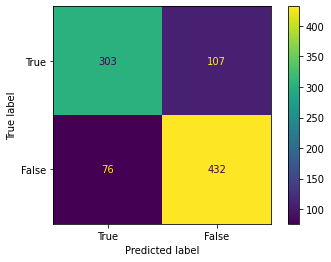

Training Measures:
Accuracy: 0.800654
Precision: 0.801484
Recall: 0.850394
F1_Score: 0.825215
Matthews correlation coefficient: 0.595159


In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

accu = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
fs = f1_score(y, y_pred)
cm = confusion_matrix(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [True, False])
cm_display.plot()
plt.show()

print('Training Measures:')
print('Accuracy: %f' % accu)
print('Precision: %f' % prec)
print('Recall: %f' % rec)
print('F1_Score: %f' % fs)
print('Matthews correlation coefficient: %f' % mcc)